# Notebook 01: Data Exploration & Quality Audit
The goal of this notebook is to perform a high-fidelity audit of the Bronze layer, validate the success of the Playwright scraper, and prototype the core logic for the Silver layer—specifically focusing on automated StatCan transformations and the LLM-driven mapping of job titles to National Occupational Classifications (NOC).

## Section 0: Setup

In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

The use of `sys.path.append` ensures the notebook can utilize the `src` package for transformation logic and Ollama configurations.

In [57]:
from src.transforms.role_mapper import map_roles
from src.transforms.skills_extractor import extract_tech_skills
from src.transforms.skills_section_extractor import extract_skills_section
from src.transforms.silver_transform import (
    transform_graduates,
    transform_income_trends,
    transform_census_income,
    transform_labour_trends,
    transform_census_labour
)

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.interpolate import make_interp_spline, UnivariateSpline

In [11]:
import duckdb
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [12]:
DB_PATH = "../data/warehouse.duckdb"

## Section 1: Connection and Schema Overview
Establish a connection to the DuckDB warehouse and verify that all expected tables were successfully ingested.

In [13]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT schema_name, table_name, estimated_size
        FROM duckdb_tables()
        WHERE schema_name = 'bronze';
    """).df())

  schema_name               table_name  estimated_size
0      bronze         job_postings_raw            6935
1      bronze     sc_census_income_raw              44
2      bronze     sc_census_labour_raw             129
3      bronze  sc_graduates_trends_raw              84
4      bronze     sc_labour_trends_raw              48
5      bronze      sc_wages_trends_raw              16


The row counts confirm that all six tables (5 StatCan, 1 Adzuna) were successfully populated, providing a complete raw dataset for audit.

## Section 2: NOC Alignment & Taxonomy Consolidation
The [2021 National Occupational Classification (NOC)](https://noc.esdc.gc.ca/Structure/Hierarchy) provides a granular breakdown of technical roles. To optimize our SkillPath-Engine, we would map our scraped titles to the following core units:
- **21210 (Math & Stats):** Develops and applies mathematical or statistical techniques to solve complex problems and assess financial risk.
- **21211 (Data Science):** Uses advanced analytics, machine learning, and predictive modeling to extract insights from unstructured data.
- **21220 (Cybersecurity):** Plans and implements security measures to protect networks, devices, and organizational information.
- **21221 (Business Systems):** Translates corporate strategic objectives into technical IT architectures and tasks.
- **21222 (Information Systems):** Analyzes and assesses system requirements while implementing information development plans and policies.
- **21223 (Database & Data Admin):** Designs, develops, and administers data management solutions and administration standards.
- **21230 (Systems Programming):** Writes and tests code for software applications, operating systems, and communications software.
- **21231 (Software Engineering):** Researches and designs technical environments, embedded software, and information warehouses.
- **21232 (Software Development):** Designs and writes code for new systems to ensure overall efficiency and effectiveness.
- **21233 (Web Design):** Develops the visual layout, presentation, and user-interface functionality of websites.
- **21234 (Web Development):** Uses programming languages to create, modify, and integrate website capacity and performance.

## Section 3: StatCan Bronze Profiling & Silver Prototyping
In this phase, we validate the `statcan_silver_factory` logic to ensure raw StatCan datasets are correctly pivoted and standardized for downstream joins.

The transformation process includes:
- **Schema Standardization:** Leveraging the "Silver Factory" to drop redundant constant columns and map generic `VALUE` fields to descriptive aliases, ensuring the data is both human-readable and analytics-ready.
- **Dimensional Pivoting:** Prototyping the pivot transformation to flatten time-series data and categorical dimensions into a structured, single-row format per NOC code.

### 3.1. Transformation: Census Income 2021

In [14]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_census_income_raw);
    """).df())

                                          column_name column_type  NULL
0                                           Geography     VARCHAR  <NA>
1                                          Gender (3)     VARCHAR  <NA>
2                                             Age (4)     VARCHAR  <NA>
3         Highest certificate, diploma or degree (16)     VARCHAR  <NA>
4   Major field of study - Classification of Instr...     VARCHAR  <NA>
5        Work activity during the reference year (4A)     VARCHAR  <NA>
6   Occupation - Unit group - National Occupationa...     VARCHAR  <NA>
7                    Employment income statistics (7)     VARCHAR  <NA>
8                                            REF_DATE     VARCHAR  <NA>
9                                               VALUE      DOUBLE  <NA>
10                                                pid     VARCHAR  <NA>
11                                        ingested_at   TIMESTAMP  <NA>
12                                             source     VARCHA

In [58]:
census_income = transform_census_income()
census_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   education_level  44 non-null     object        
 1   occupation       44 non-null     object        
 2   median_income    42 non-null     float64       
 3   ingested_at      44 non-null     datetime64[us]
 4   source           44 non-null     object        
 5   noc_code         44 non-null     object        
 6   noc_5            40 non-null     object        
 7   noc_3            44 non-null     object        
dtypes: datetime64[us](1), float64(1), object(6)
memory usage: 2.9+ KB


### 3.2. Transformation: Annual Wages

In [16]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_wages_trends_raw);
    """).df())

                                   column_name column_type  NULL
0                                    Geography     VARCHAR  <NA>
1                                        Wages     VARCHAR  <NA>
2                                 Type of work     VARCHAR  <NA>
3   National Occupational Classification (NOC)     VARCHAR  <NA>
4                                       Gender     VARCHAR  <NA>
5                                    Age group     VARCHAR  <NA>
6                                     REF_DATE     VARCHAR  <NA>
7                                        VALUE      DOUBLE  <NA>
8                                          pid     VARCHAR  <NA>
9                                  ingested_at   TIMESTAMP  <NA>
10                                      source     VARCHAR  <NA>


In [59]:
income_trends = transform_income_trends()
income_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   occupation     16 non-null     object        
 1   date           16 non-null     datetime64[ns]
 2   weekly_wages   16 non-null     float64       
 3   ingested_at    16 non-null     datetime64[us]
 4   source         16 non-null     object        
 5   noc_code       16 non-null     object        
 6   noc_5          0 non-null      object        
 7   noc_3          16 non-null     object        
 8   median_income  16 non-null     float64       
dtypes: datetime64[ns](1), datetime64[us](1), float64(2), object(5)
memory usage: 1.2+ KB


### 3.3. Transformation: Census Labour Force Status 2021

In [20]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_census_labour_raw);
    """).df())

                                          column_name column_type  NULL
0                                           Geography     VARCHAR  <NA>
1         Highest certificate, diploma or degree (16)     VARCHAR  <NA>
2                                           Age (15A)     VARCHAR  <NA>
3                                          Gender (3)     VARCHAR  <NA>
4   Occupation - Unit group - National Occupationa...     VARCHAR  <NA>
5                             Labour force status (3)     VARCHAR  <NA>
6                                            REF_DATE     VARCHAR  <NA>
7                                               VALUE      DOUBLE  <NA>
8                                                 pid     VARCHAR  <NA>
9                                         ingested_at   TIMESTAMP  <NA>
10                                             source     VARCHAR  <NA>


In [60]:
census_labour = transform_census_labour()
census_labour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   education_level    44 non-null     object        
 1   occupation         44 non-null     object        
 2   ingested_at        44 non-null     datetime64[us]
 3   source             44 non-null     object        
 4   employed           44 non-null     float64       
 5   unemployed         41 non-null     float64       
 6   noc_code           44 non-null     object        
 7   noc_5              40 non-null     object        
 8   noc_3              44 non-null     object        
 9   labour_force       41 non-null     float64       
 10  unemployment_rate  41 non-null     float64       
dtypes: datetime64[us](1), float64(4), object(6)
memory usage: 3.9+ KB


### 3.4. Transformation: Annual Labour Force Status

In [24]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_labour_trends_raw);
    """).df())

                                  column_name column_type  NULL
0                                   Geography     VARCHAR  <NA>
1                Labour force characteristics     VARCHAR  <NA>
2  National Occupational Classification (NOC)     VARCHAR  <NA>
3                                      Gender     VARCHAR  <NA>
4                                    REF_DATE     VARCHAR  <NA>
5                                       VALUE      DOUBLE  <NA>
6                                         pid     VARCHAR  <NA>
7                                 ingested_at   TIMESTAMP  <NA>
8                                      source     VARCHAR  <NA>


In [61]:
labour_trends = transform_labour_trends()
labour_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   occupation                16 non-null     object        
 1   date                      16 non-null     datetime64[ns]
 2   ingested_at               16 non-null     datetime64[us]
 3   source                    16 non-null     object        
 4   labour force              16 non-null     float64       
 5   proportion of employment  16 non-null     float64       
 6   unemployment rate         16 non-null     float64       
 7   noc_code                  16 non-null     object        
 8   noc_5                     0 non-null      object        
 9   noc_3                     16 non-null     object        
dtypes: datetime64[ns](1), datetime64[us](1), float64(3), object(5)
memory usage: 1.4+ KB


### 3.5. Transformation: Annual Graduates

In [28]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.sc_graduates_trends_raw);
    """).df())

                                         column_name column_type  NULL
0                                          Geography     VARCHAR  <NA>
1  International Standard Classification of Educa...     VARCHAR  <NA>
2                                     Field of study     VARCHAR  <NA>
3                                   Institution type     VARCHAR  <NA>
4                                             Gender     VARCHAR  <NA>
5                                           REF_DATE     VARCHAR  <NA>
6                                              VALUE      DOUBLE  <NA>
7                                                pid     VARCHAR  <NA>
8                                        ingested_at   TIMESTAMP  <NA>
9                                             source     VARCHAR  <NA>


In [62]:
graduates = transform_graduates()
graduates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   education_level  84 non-null     object        
 1   field_of_study   84 non-null     object        
 2   date             84 non-null     datetime64[ns]
 3   graduates        84 non-null     float64       
 4   ingested_at      84 non-null     datetime64[us]
 5   source           84 non-null     object        
 6   noc_code         84 non-null     object        
 7   noc_5            0 non-null      object        
 8   noc_3            84 non-null     object        
dtypes: datetime64[ns](1), datetime64[us](1), float64(1), object(6)
memory usage: 6.0+ KB


## Section 4: Job Market Distribution & Scraper Validation
Here, we measure the density of the labor market data and verify that the Playwright scraper successfully retrieved full-text job descriptions.

### 4.1. Scraper Efficiency Check

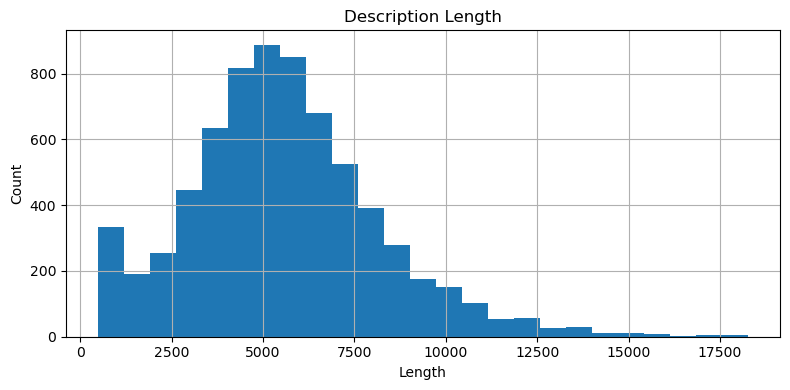

In [30]:
with duckdb.connect(DB_PATH) as con:
    con.execute(f"""
        SELECT LENGTH(description) as text_length
        FROM bronze.job_postings_raw;
    """).df().round(2).hist(bins=25, figsize=(8,4))
    plt.title("Description Length")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.tight_layout()

An average description length of 5538 characters confirms the Playwright implementation successfully bypassed Adzuna's 500-character snippet limit.

### 4.2. NOC and Search Term Density

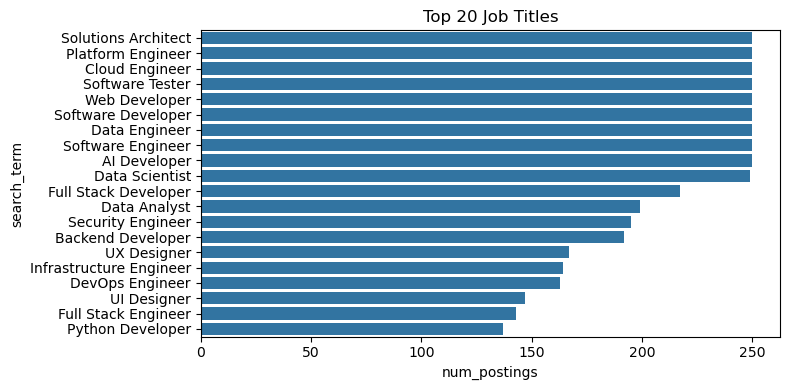

In [31]:
with duckdb.connect(DB_PATH) as con:
    noc_distribution_df = con.execute("""
        SELECT
            search_term,
            COUNT(*) AS num_postings,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 5) AS pct_postings
        FROM bronze.job_postings_raw
        GROUP BY search_term
        ORDER BY num_postings DESC;
    """).df()

    plt.figure(figsize=(8,4))
    sns.barplot(
        noc_distribution_df.head(20), 
        x="num_postings", y="search_term"
    )
    plt.title("Top 20 Job Titles")
    plt.tight_layout()
    plt.show()

The results show significant volume for technical roles, providing a robust statistical sample for the skill-extraction phase.

## Section 6: Semantic Role Mapping (Job Titles to NOC)
The goal here is to align varied job titles with the standardized NOC taxonomy using Sentence Transformers and optimize the mapping threshold using derivative analysis.

### 6.1. Job Postings Schema and Nulls Check

In [32]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute("""
        SELECT column_name, column_type, null
        FROM (DESCRIBE TABLE bronze.job_postings_raw);
    """).df())

   column_name column_type  NULL
0     job_hash     VARCHAR  <NA>
1  description     VARCHAR  <NA>
2  search_term     VARCHAR  <NA>
3  ingested_at   TIMESTAMP  <NA>
4       source     VARCHAR  <NA>
5  raw_payload        JSON  <NA>


In [33]:
with duckdb.connect(DB_PATH) as con:
    job_postings = con.execute("""
        SELECT
            search_term, 
            REPLACE(raw_payload->'title', '\"', '') as job_title,
            REPLACE(raw_payload->'company'->'display_name', '\"', '') as company,
            description,
            raw_payload
        FROM bronze.job_postings_raw;
    """).df()

In [34]:
job_postings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6935 entries, 0 to 6934
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   search_term  6935 non-null   object
 1   job_title    6935 non-null   object
 2   company      6925 non-null   object
 3   description  6935 non-null   object
 4   raw_payload  6935 non-null   object
dtypes: object(5)
memory usage: 271.0+ KB


### 6.2. NOC Mapping (Semantic Mathcing)

In [35]:
%%time
mapped_jobs = map_roles(job_postings, yaml_path="../config/role_mapping.yaml", full_report=True)

CPU times: total: 10min 39s
Wall time: 1min 24s


Using semantic similarity instead of keyword matching allows the system to correctly map "Frontend Wizard" to a technical NOC code. We accomplished this using a transformer (`all-MiniLM-L6-v2`).

### 6.3. Confidence Score Distribution & Threshold Optimization

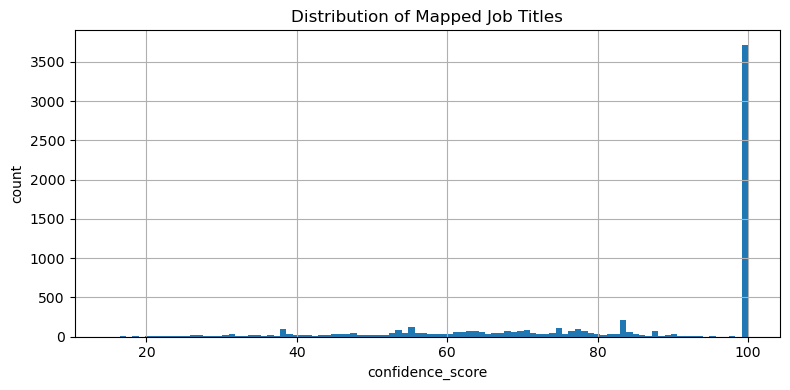

In [36]:
mapped_jobs["confidence_score"].hist(bins=100, figsize=(8,4))
plt.title("Distribution of Mapped Job Titles")
plt.xlabel("confidence_score")
plt.ylabel("count")
plt.tight_layout()

#### Finding the Optimal Threshold
We use a derivative-based approach to find the "steepest point" of data retention as a way to mathematically justify the cutoff for mapping quality.

In [37]:
thresholds = np.arange(0, 101, 1)
percentages = []
for t in thresholds:
    mask = mapped_jobs['confidence_score'] >= t
    pct = 100 * len(mapped_jobs[mask]) / len(mapped_jobs)
    percentages.append(pct)

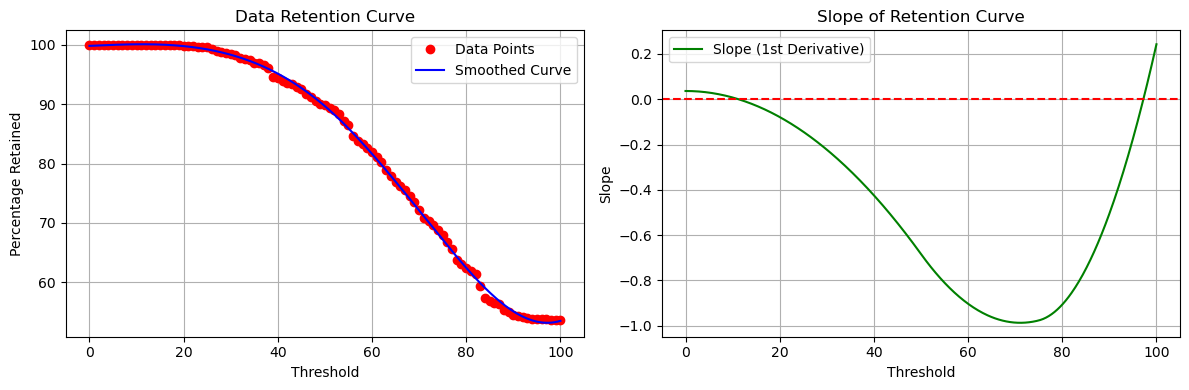

In [38]:
spline = UnivariateSpline(thresholds, percentages, s=20)
x_smooth = np.linspace(thresholds.min(), thresholds.max(), 500)
y_smooth = spline(x_smooth)
y_der = spline.derivative()(x_smooth)
# Plotting to verify
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)

plt.plot(thresholds, percentages, 'ro', label='Data Points')
plt.plot(x_smooth, y_smooth, 'b-', label='Smoothed Curve')
plt.title('Data Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Percentage Retained')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_smooth, y_der, 'g-', label='Slope (1st Derivative)')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Slope of Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Slope')
plt.legend()
plt.grid(True)

plt.tight_layout()

In [39]:
steepest_idx = np.argmin(y_der)
optimal_t = x_smooth[steepest_idx]
print(f"The Steepest Point (cliff): {optimal_t:.2f}")
print(f"~%{percentages[int(np.round(optimal_t,0))]:.1f} of data is retained with a threshold of {np.round(optimal_t,0)}")

The Steepest Point (cliff): 71.14
~%70.8 of data is retained with a threshold of 71.0


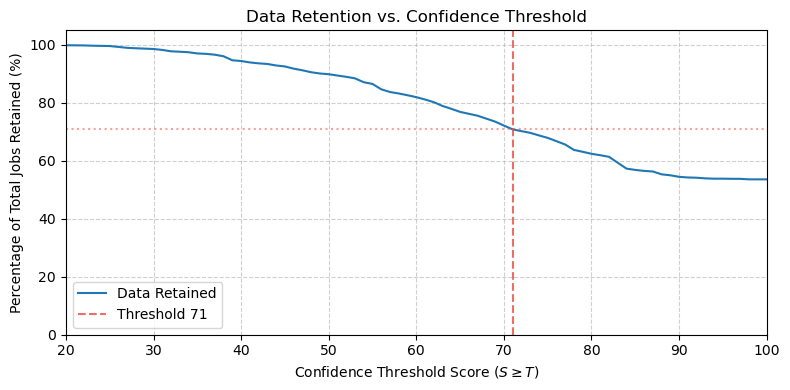

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, percentages, label='Data Retained')

# Highlight the "Recommended Threshold"
RECOMMENDED_T = int(np.round(optimal_t, 0))
retention_at_T = percentages[RECOMMENDED_T]

plt.axvline(x=RECOMMENDED_T, color='#e74c3c', linestyle='--', alpha=0.8, label=f'Threshold {RECOMMENDED_T}')
plt.axhline(y=retention_at_T, color='#e74c3c', linestyle=':', alpha=0.5)

plt.title("Data Retention vs. Confidence Threshold")
plt.xlabel("Confidence Threshold Score ($S \geq T$)")
plt.ylabel("Percentage of Total Jobs Retained (%)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.ylim(0, 105)
plt.xlim(20, 100)

plt.tight_layout()
plt.show()

#### Quality Verification

In [41]:
(mapped_jobs[mapped_jobs["confidence_score"]
     .between(optimal_t, np.ceil(optimal_t))]
     .sample(frac=1.0, random_state=42)
     .head(15))

,search_term,job_title,company,description,raw_payload,clean_title,matched_label,confidence_score,matched_noc,match_method
4666,Platform Engineer,Cloud Data & AI Engineer,OSI Digital,Job DescriptionJob DescriptionJob Title: Cloud...,"{""salary_min"": 50000, ""category"": {""__CLASS__""...",cloud data ai engineer,Cloud Engineer,71.74,21231,Semantic
6431,Web Developer,"Web Production, Senior Manager",Okta,Get to know Okta\n\nOkta is The World’s Identi...,"{""longitude"": -79.402726, ""__CLASS__"": ""Adzuna...","web production, manager",Web Developer,71.39,21234,Semantic
894,Data Engineer,Cloud Data & AI Engineer,OSI Digital,Job DescriptionJob DescriptionJob Title: Cloud...,"{""created"": ""2026-02-21T03:14:55Z"", ""__CLASS__...",cloud data ai engineer,Cloud Engineer,71.74,21231,Semantic
1925,Technical Architect,Salesforce Architect,Grazitti Interactive Inc.,Job DescriptionJob DescriptionSalary:\n\n\nGra...,"{""created"": ""2026-03-05T03:17:47Z"", ""company"":...",salesforce architect,Solutions Architect,71.35,21222,Semantic
4215,Cloud Engineer,Principal Data Strategist,Caylent,Caylent is a cloud native services company tha...,"{""location"": {""display_name"": ""Canada"", ""area""...",data strategist,Systems Strategist,71.22,21221,Semantic
3877,DevOps Engineer,Ingénieur DevOps - Taux linéaires,Crédit Agricole CIB,Informations générales\nEntité Rejoignez les é...,"{""title"": ""Ing\u00e9nieur DevOps - Taux lin\u0...",ingenieur devops - taux lineaires,DevOps Engineer,71.86,21231,Semantic
1332,Security Engineer,Principal Data Strategist,Caylent,Caylent is a cloud native services company tha...,"{""salary_is_predicted"": ""0"", ""salary_min"": 215...",data strategist,Systems Strategist,71.22,21221,Semantic
3901,DevOps Engineer,Principal Data Strategist,Caylent,Caylent is a cloud native services company tha...,"{""salary_is_predicted"": ""0"", ""__CLASS__"": ""Adz...",data strategist,Systems Strategist,71.22,21221,Semantic
3491,Systems Programmer,Mainframe DevOps Support-2,Realign LLC,"Toronto, Ontario M5V 3L9 Posted February 24th,...","{""category"": {""__CLASS__"": ""Adzuna::API::Respo...",mainframe devops support-,Mainframe Developer,71.27,21230,Semantic
2084,Solutions Architect,Senior Microsoft Solution Architect,Experienced Career,What do you think of when you hear the name MN...,"{""location"": {""area"": [""Canada"", ""Ontario"", ""T...",microsoft architect,Business Architect,71.65,21221,Semantic


Reviewing the 15 rows around the 71.0 threshold confirms that the semantic mapping remains accurate even at the lower bounds of the "optimal" data retention.

## Section 7: Knowledge Graph Feasibility (Ollama/Gemma 3)
The purpose is to demonstrate the feasibility of using local LLM inference to extract structured skills from the high-volume text retrieved in Section 3.

In [43]:
selected_cols = ["matched_noc", "job_title", "matched_label", "company", "description", "confidence_score"]
mask = mapped_jobs["confidence_score"] >= optimal_t
sample_jobs = mapped_jobs.loc[mask, selected_cols].sample(n=100, random_state=42).copy()

In [44]:
sample_jobs.shape

(100, 6)

### Preprocess Job Descriptions

In [45]:
sample_desc = sample_jobs.sample(n=1, random_state=42)['description'].values[0]
len(sample_desc)

9953

In [46]:
print(extract_skills_section(sample_desc))

Demonstrated track record of shipping large, complex software projects in production environments

Fluency in Ruby and experience working with Python or Typescript

Experience with PostgreSQL or other relational databases

Experience contributing to architectural design and technical decision-making

Ability to articulate the value and trade-offs of technical investments

Experience mentoring engineers through code reviews, pairing, or informal leadership

Familiarity with modern JavaScript frameworks such as React, Vue, or Angular

Experience operating within Agile/Scrum development environments

Working Style & Environment

Comfortable in a fast-paced startup environment with evolving priorities

Ability to operate independently with limited technical guidance

Strong communication skills and cross-functional collaboration experience

Located in Central or Eastern US time zones (CDT or EDT) strongly preferred


### LLM Skills Entity Extraction Test

In [47]:
def extract_skills(desc):
    if not desc or len(str(desc)) < 10:
        return None
    try:
        skills_section = extract_skills_section(desc)
        data = extract_tech_skills(skills_section)
        return [s.skill_name for s in data.technical_skills]
    except Exception as e:
        print("Error processing row", e)
        return None

In [48]:
%%time
extract_skills(sample_desc)

CPU times: total: 219 ms
Wall time: 24.5 s


['Ruby',
 'Python',
 'Typescript',
 'PostgreSQL',
 'React',
 'Vue',
 'Angular',
 'Git']

### Stress Test

In [49]:
%%time
sample_jobs["skills"] = sample_jobs["description"].apply(extract_skills)

CPU times: total: 1.36 s
Wall time: 7min 52s


In [50]:
sample_jobs.head()

,matched_noc,job_title,matched_label,company,description,confidence_score,skills
6647,21231,Software Engineer III - Frontend (ReactJS),Software Engineer,Emburse,"Who We Are:\nAt Emburse, you’ll not just imagi...",100.00,"[React, Angular, MySQL, Git, REST, AWS, Azure,..."
5142,21231,Senior Site Reliability Engineer (Hybrid),Site Reliability Engineer,Broadridge,"At Broadridge, we've built a culture where the...",100.00,"[Linux, Windows, Terraform, Bladelogic, Chef, ..."
1291,21220,Cybersecurity Compliance Analyst,Information Security Analyst,TC Energy,"Determined, imaginative, curious—if these are ...",78.54,"[TCP/IP, WAN/LAN, Firewall, NIST Cybersecurity..."
4290,21231,Staff Frontend Infrastructure Engineer - Vanco...,Cloud Engineer,Giga,About Giga\n\nGiga has recently raised a $61M ...,100.00,"[TypeScript, React, Next.js, ESLint, Prettier,..."
4681,21232,Java Full Stack Developer,Full Stack Developer,Northwest Talent Solutions LLC,Job DescriptionJob Description\n\nJava Full-St...,100.00,"[Java, Spring Boot, Angular, SQL, Oracle, PL/S..."


A wall time of ~5.8 seconds per extraction suggests that while the quality is high, Phase 4 will require a batch-processing strategy to handle thousands of postings.